###**Deep Learning Assignment-3**

**Name:** Yesha Pandya

**Enrollment Number:** 23BT04175

**Div:** 1 **Batch:** C

#### **1. Setup and Data Preprocessing**
In this section, we import the necessary libraries, including TensorFlow and Keras. We then load the standard MNIST dataset of handwritten digits directly from Keras. To help the neural network learn more efficiently, we normalize the pixel values by dividing the arrays by 255, scaling them to a range between 0 and 1.

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd

# Load the MNIST dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize the data by dividing by 255
X_train = X_train / 255.0
X_test = X_test / 255.0

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


#### **2. Dynamic Model Builder**
To fulfill the assignment requirements, we need to test networks with 1 to 5 layers, using different activation functions and optimizers. Instead of writing out 5 different models manually, this function dynamically builds an Artificial Neural Network (ANN) based on the parameters we pass to it.

It uses a `Flatten` layer so we don't have to manually reshape the 28x28 image arrays beforehand. The hidden layers use 100 neurons , and the output layer uses 10 neurons (one for each digit 0-9). We compile it using `sparse_categorical_crossentropy` for the loss function, which is ideal for integer-labeled classes.

In [ ]:
def evaluate_ann(total_layers, hidden_activation, optimizer, output_activation):
    """
    Builds and evaluates a neural network with the specified parameters.
    total_layers includes the output layer.
    """
    model = keras.Sequential()

    # Flatten layer to handle the 28x28 2D arrays
    model.add(keras.layers.Flatten(input_shape=(28, 28)))

    # Add hidden layers (total_layers - 1, since the last is the output layer)
    for _ in range(total_layers - 1):
        model.add(keras.layers.Dense(100, activation=hidden_activation))

    # Add the output layer (10 neurons for digits 0-9)
    model.add(keras.layers.Dense(10, activation=output_activation))

    # Compile the model
    model.compile(optimizer=optimizer,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    # Train the model (using 5 epochs to keep training time manageable)
    model.fit(X_train, y_train, epochs=5, verbose=0)

    # Evaluate the model on the test set
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

    return accuracy

#### **3. Running the Experiments**
Here, we define the hyperparameters we want to test:
* **Layers**: 1, 2, 3, 4, 5
* **Hidden Activations**: `relu`, `tanh`
* **Output Activations**: `softmax`, `sigmoid`
* **Optimizers**: `adam`, `sgd`

We loop through all these combinations, train a model for each, and store the resulting test accuracy. *(Note: This cell will take a few minutes to run since it is training multiple models.)*

In [ ]:
# Define the hyperparameters to test
layer_counts = [1, 2, 3, 4, 5]
hidden_activations = ['relu', 'tanh']
optimizers = ['adam', 'sgd']
output_activations = ['softmax', 'sigmoid']

results = []

print("Running experiments... Please wait.")

for layers in layer_counts:
    for h_act in hidden_activations:
        # If it's a 1-layer network, there are no hidden layers, so skip redundant runs
        if layers == 1 and h_act != hidden_activations[0]:
            continue

        for opt in optimizers:
            for o_act in output_activations:
                # Get accuracy for this combination
                acc = evaluate_ann(layers, h_act, opt, o_act)

                # Record the results
                results.append({
                    'Total Layers': layers,
                    'Hidden Activation': h_act if layers > 1 else 'None (Flatten only)',
                    'Output Activation': o_act,
                    'Optimizer': opt,
                    'Test Accuracy': round(acc, 4)
                })

print("All experiments completed successfully.")

Running experiments... Please wait.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


All experiments completed successfully.


#### **4. Results and Comparison**
Finally, we take the dictionary of results, convert it into a Pandas DataFrame, and sort it by the highest test accuracy so we can easily compare which architecture and hyperparameter combination performed the best.

In [ ]:
# Create a DataFrame from the results
results_df = pd.DataFrame(results)

# Sort by Test Accuracy in descending order to see the best performers first
results_df = results_df.sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)

# Format the accuracy as a percentage for better readability
results_df['Test Accuracy'] = (results_df['Test Accuracy'] * 100).astype(str) + '%'

# Display the final comparison table
display(results_df)

,Total Layers,Hidden Activation,Output Activation,Optimizer,Test Accuracy
0,2,relu,sigmoid,adam,97.74000000000001%
1,4,relu,sigmoid,adam,97.72999999999999%
2,2,relu,softmax,adam,97.61%
3,3,relu,sigmoid,adam,97.6%
4,3,relu,softmax,adam,97.58%
5,4,relu,softmax,adam,97.54%
6,3,tanh,sigmoid,adam,97.48%
7,5,tanh,softmax,adam,97.39999999999999%
8,4,tanh,sigmoid,adam,97.36%
9,5,relu,softmax,adam,97.34%


Training final model for predictions...
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9226 - loss: 0.2726
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9637 - loss: 0.1227
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9742 - loss: 0.0856
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9807 - loss: 0.0639
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9843 - loss: 0.0503

Generating predictions...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 822us/step


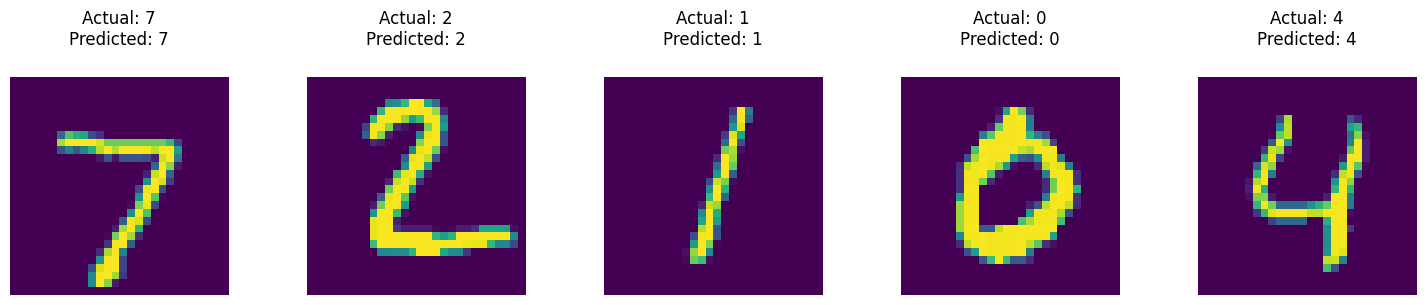

In [ ]:
import matplotlib.pyplot as plt

# 1. Build a final model with a high-performing configuration
final_model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

final_model.compile(optimizer='adam',
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

# Train the model
print("Training final model for predictions...")
final_model.fit(X_train, y_train, epochs=5, verbose=1)

# 2. Make predictions on the test dataset
print("\nGenerating predictions...")
y_predicted = final_model.predict(X_test)

# The model outputs 10 probabilities per image (one for each digit).
# We use np.argmax to find the index (digit) with the highest probability.
y_predicted_labels = [np.argmax(i) for i in y_predicted]

# 3. Visualize the first 5 test images with their predicted labels
fig, axes = plt.subplots(1, 5, figsize=(15, 3))

for i in range(5):
    # Plot the image
    axes[i].matshow(X_test[i], cmap='viridis')

    # Add the actual vs predicted labels as the title
    actual_label = y_test[i]
    predicted_label = y_predicted_labels[i]
    axes[i].set_title(f"Actual: {actual_label}\nPredicted: {predicted_label}")

    # Hide the axes ticks for a cleaner look
    axes[i].axis('off')

plt.tight_layout()
plt.show()